In [40]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv('data/studper.csv')

In [42]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [43]:
df.shape

(1000, 8)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [45]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [48]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


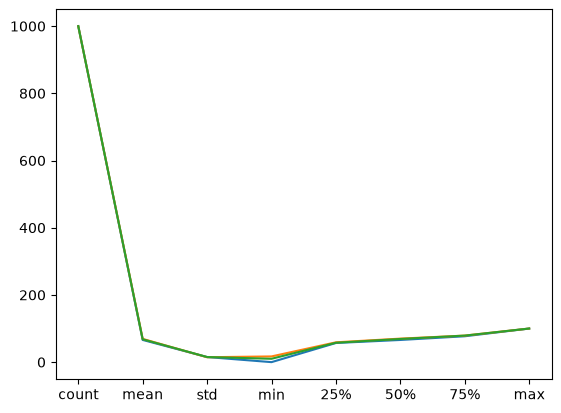

In [49]:
plt.plot(df.describe())

In [50]:
print("categories in 'gender' variable:    ",end=" ")
print(df['gender'].unique())

print("categories in 'race/ethnicity' variable:    ",end=" ")
print(df['race/ethnicity'].unique())

print("categories in 'parental level of education' variable:    ",end=" ")
print(df['parental level of education'].unique())

print("categories in 'lunch' variable:    ",end=" ")
print(df['lunch'].unique())

print("categories in 'test preparation course' variable:    ",end=" ")
print(df['test preparation course'].unique())



categories in 'gender' variable:     <StringArray>
['female', 'male']
Length: 2, dtype: str
categories in 'race/ethnicity' variable:     

KeyError: 'race/ethnicity'

In [ ]:
# numerical_feature = [feature for feature in df.columns if df[feature].dtype != 'O']
# categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'O']
# print('we have {} numerical feature : {} '.format(len(numerical_feature),numerical_feature))
# print('we have {} categorical feature : {} '.format(len(categorical_feature),categorical_feature))

In [ ]:
# Numerical columns
numerical_feature = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Categorical columns
categorical_feature = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"We have {len(numerical_feature)} numerical features: {numerical_feature}")
print(f"We have {len(categorical_feature)} categorical features: {categorical_feature}")

We have 3 numerical features: ['math score', 'reading score', 'writing score']
We have 5 categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [ ]:
df['total_score']=df['math score']+df['reading score']+df['writing score']
df['average']=df['total_score']/3

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [ ]:
reading_full=df[df['reading score']==100]['average'].count()
writing_full=df[df['writing score']==100]['average'].count()
math_full=df[df['math score']==100]['average'].count()

print(f"number of students with full marks in maths : {math_full} ")
print(f"number of students with full marks in writing : {writing_full} ")
print(f"number of students with full marks in reading : {reading_full} ")

number of students with full marks in maths : 7 
number of students with full marks in writing : 14 
number of students with full marks in reading : 17 


In [ ]:
reading_less_20=df[df['reading score']<=20]['average'].count()
writing_less_20=df[df['writing score']<=20]['average'].count()
math_less_20=df[df['math score']<=20]['average'].count()

print(f"number of students with less than 20 marks in maths : {math_less_20} ")
print(f"number of students with less than 20 marks in writing : {writing_less_20} ")
print(f"number of students with less than 20 marks in reading : {reading_less_20} ")

number of students with less than 20 marks in maths : 4 
number of students with less than 20 marks in writing : 3 
number of students with less than 20 marks in reading : 1 


In [ ]:
import seaborn as sns

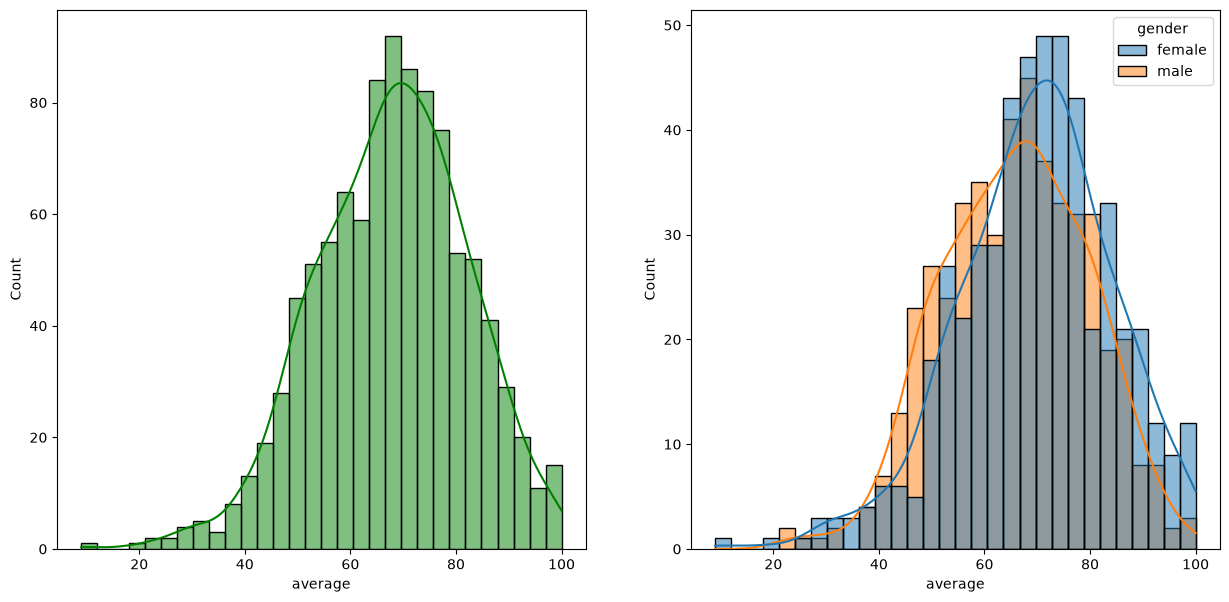

In [ ]:
fig,axe=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df['average'],bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='gender')
plt.show()

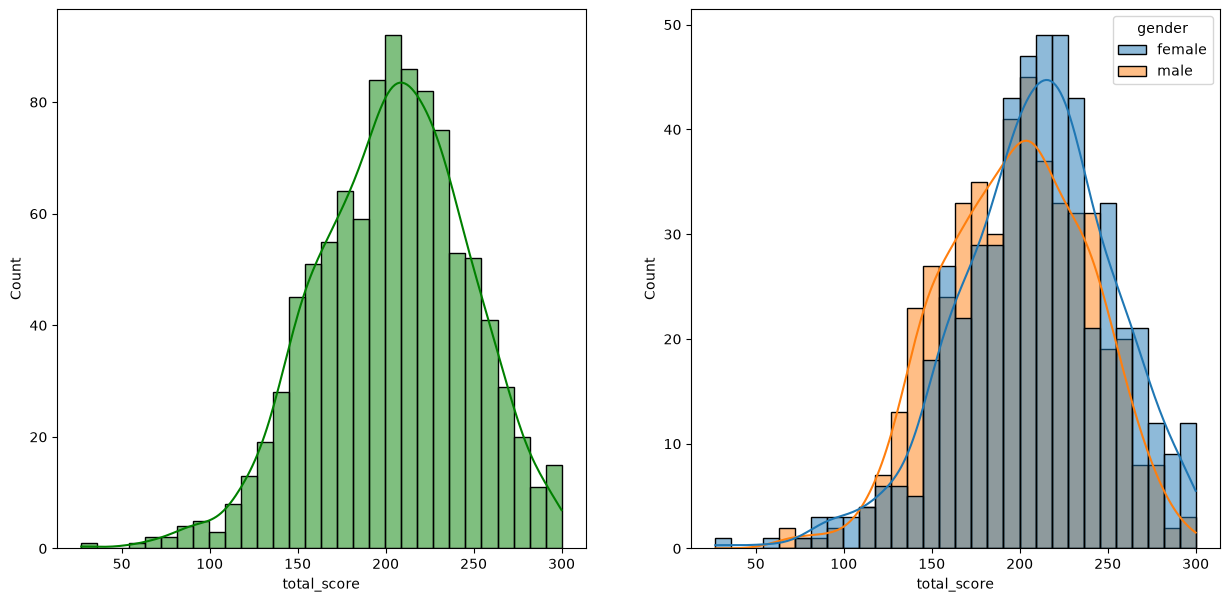

In [ ]:
fig,axe=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df['total_score'],bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',bins=30,kde=True,hue='gender')
plt.show()

<Axes: xlabel='average', ylabel='Count'>

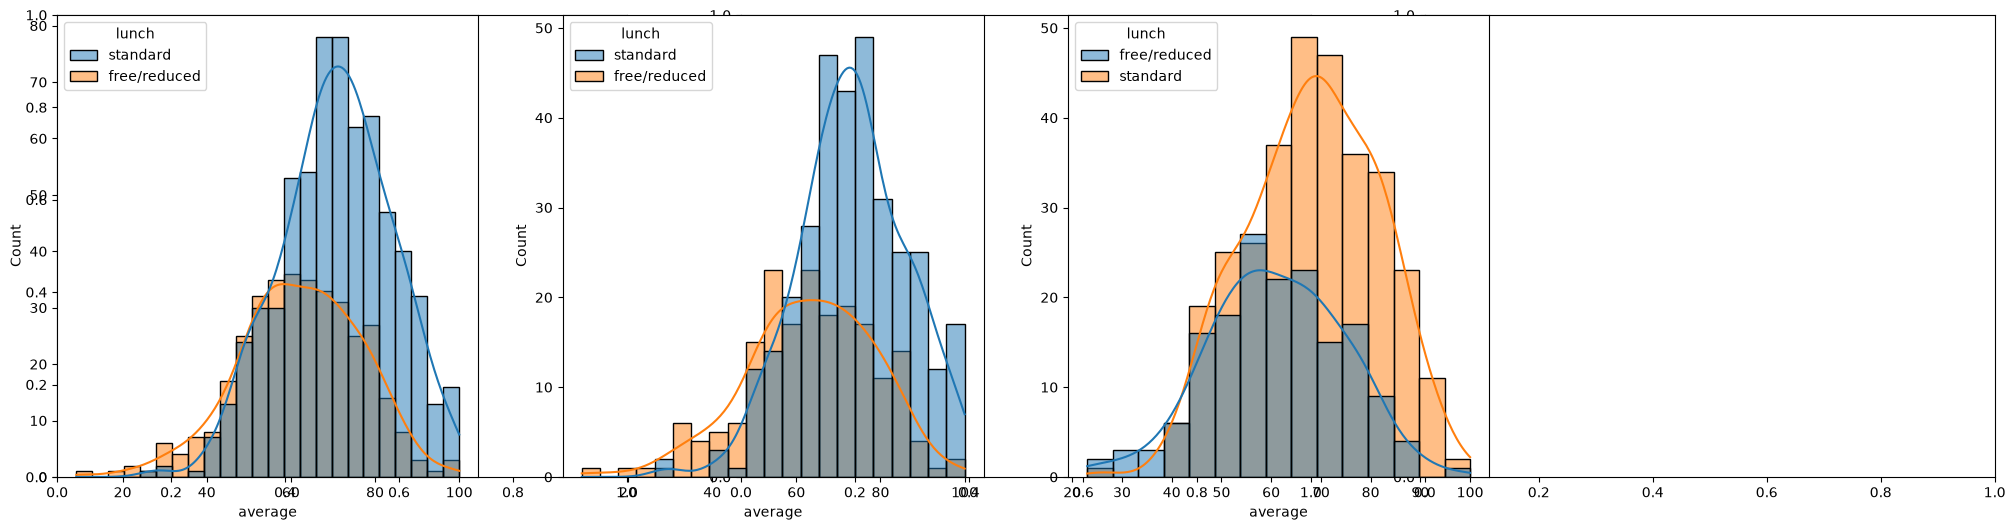

In [ ]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'],x='average',kde=True,hue='lunch')
plt.subplot(143)


<Axes: >

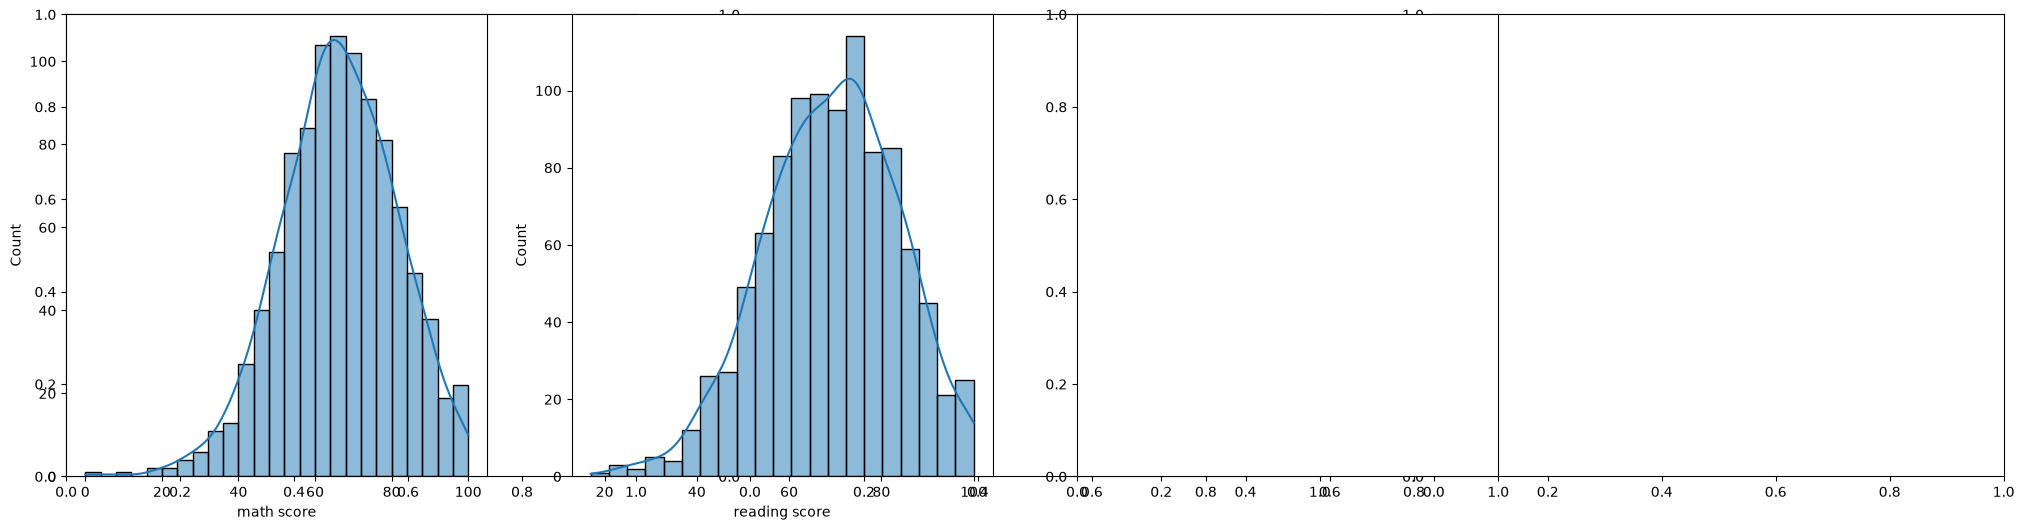

In [ ]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(df["math score"],kde=True)
plt.subplot(142)
sns.histplot(df["reading score"],kde=True)
plt.subplot(143)
# sns.histplot(df["writing score"],kde=True)
# plt.subplot(14)

<Axes: >

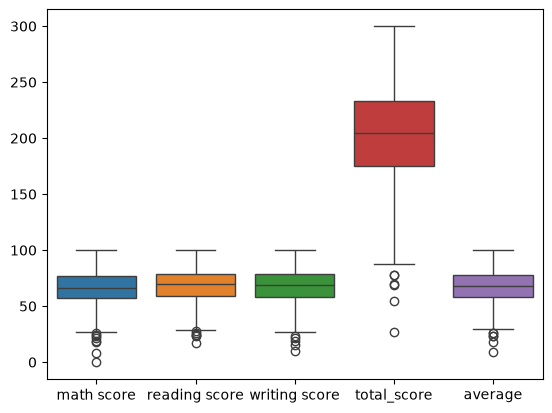

In [ ]:
sns.boxplot(data=df)

<Axes: >

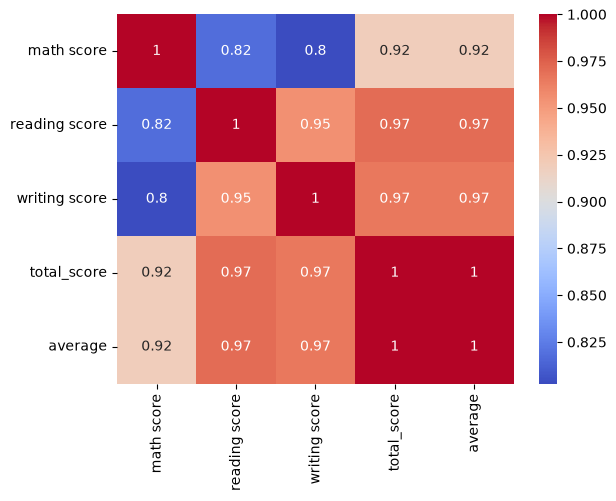

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

In [ ]:
df['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

<Axes: xlabel='race/ethnicity', ylabel='average'>

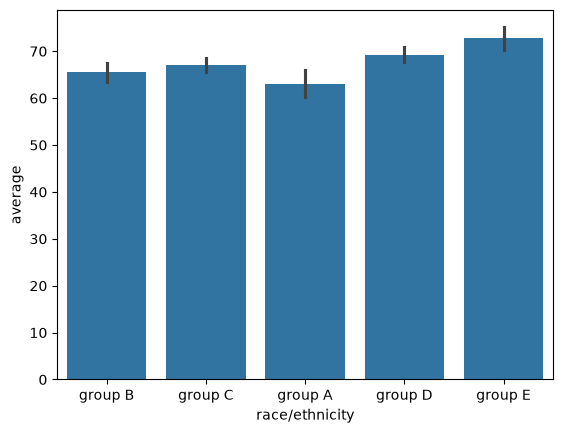

In [ ]:
sns.barplot(data=df,x="race/ethnicity",y="average")

In [ ]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

<Axes: xlabel='parental level of education', ylabel='average'>

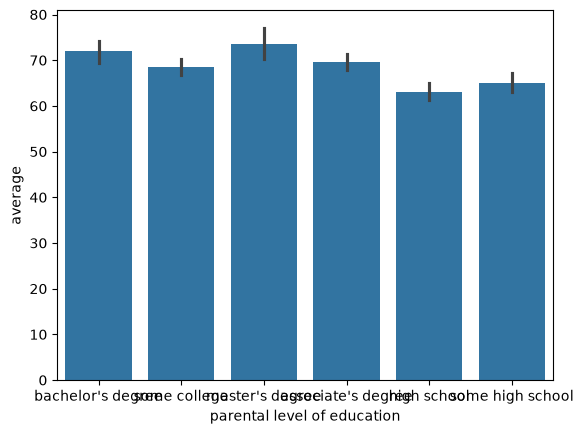

In [ ]:
sns.barplot(data=df,x="parental level of education",y="average")

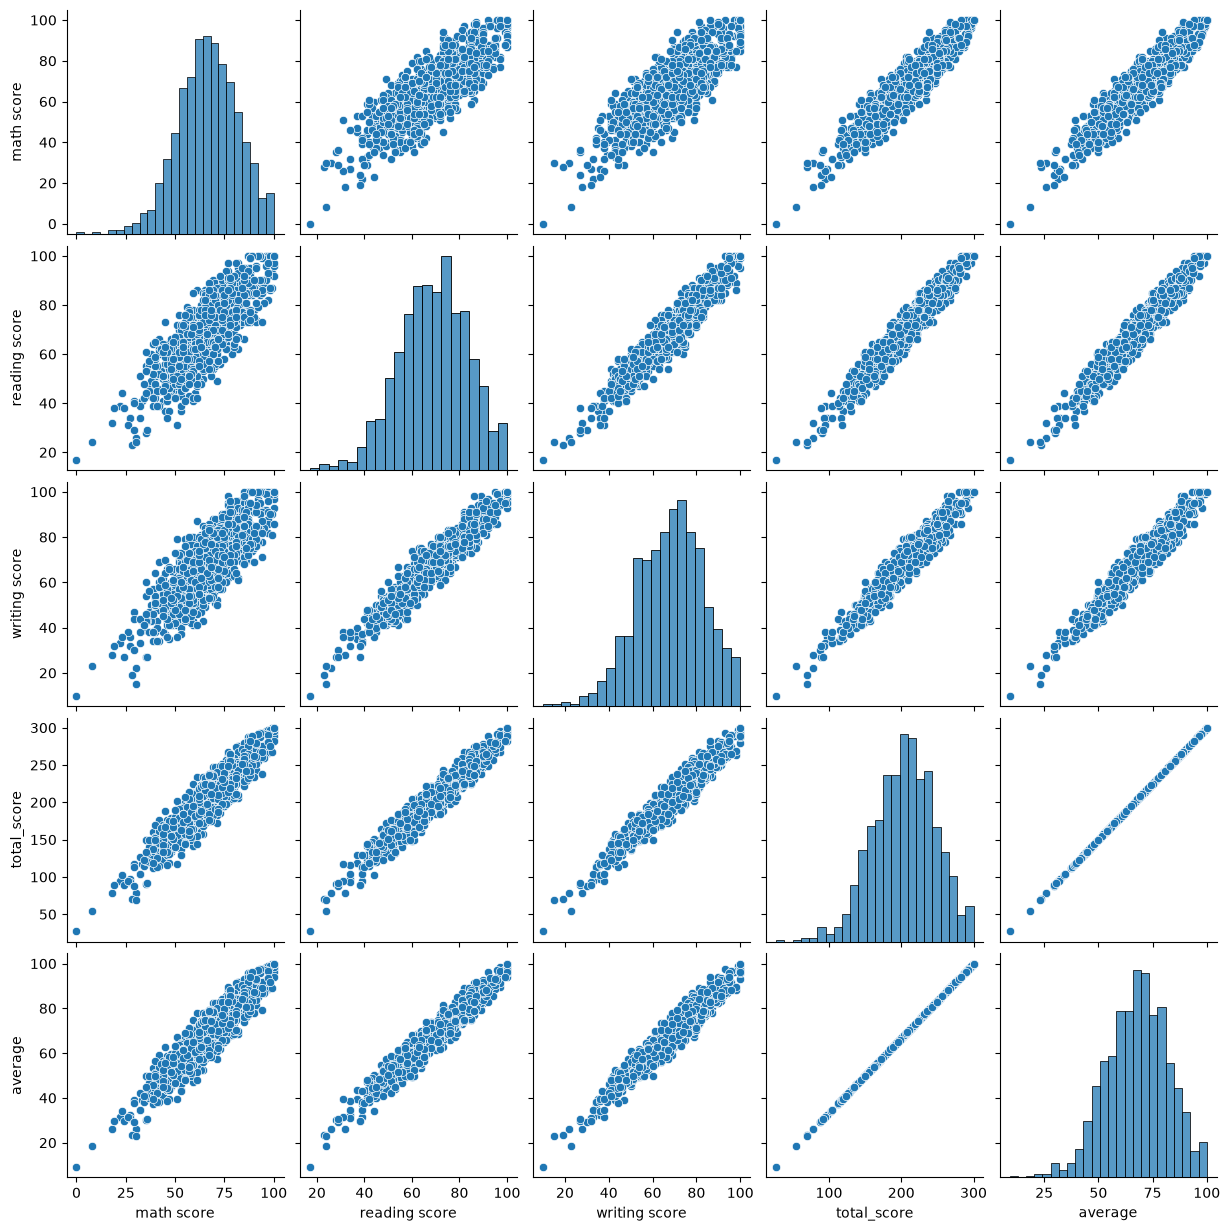

In [ ]:
sns.pairplot(df)

In [ ]:
df["result"] = np.where(
    df["average"]>=40,
    "Pass",
    "Fail"
)

In [ ]:
df['result']

0      Pass
1      Pass
2      Pass
3      Pass
4      Pass
       ... 
995    Pass
996    Pass
997    Pass
998    Pass
999    Pass
Name: result, Length: 1000, dtype: str

<Axes: xlabel='result', ylabel='average'>

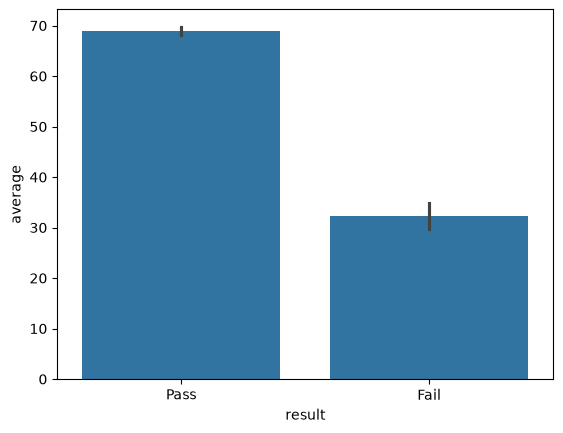

In [ ]:
sns.barplot(data=df,x="result",y="average")

In [ ]:
print(np.mean(df['total_score']))
print(np.mean(df['average']))


203.312
67.77066666666666


In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average,result
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Pass
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Pass
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Pass
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Pass
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000,Pass
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333,Pass
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000,Pass
998,female,group D,some college,standard,completed,68,78,77,223,74.333333,Pass


In [ ]:
df.to_csv("data/studFErng.csv", index=False)

In [ ]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average,result
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Pass
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Pass
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Pass
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Pass
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000,Pass
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333,Pass
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000,Pass
998,female,group D,some college,standard,completed,68,78,77,223,74.333333,Pass


In [ ]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average,result
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Pass
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Pass
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Pass
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Pass
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000,Pass
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333,Pass
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000,Pass
998,female,group D,some college,standard,completed,68,78,77,223,74.333333,Pass
